# Differential ages to H(z), Borghi et al. 2022b

In [1]:
import sys
import numpy as np
from astropy import units as u
from scipy.stats import median_abs_deviation
sys.path.append("..")
from astropy.cosmology import FlatLambdaCDM
import matplotlib.pyplot as plt
import corner
import pandas as pd
from pathlib import Path

In [2]:
# Goal is to reproduce the 4 H(z) values from 2022 Borghi paper, and check perturbations (e.g. effect of varying Lick indices)

- `comment='#'` skips the provenance header
- one row per spectrum, not per galaxy

In [3]:
matches_path = Path.cwd() / '../data/processed/borghi2022_legac_dr2/borghi2022_legac_dr2_spectrum_matches copy.tsv'

df = pd.read_csv(matches_path, sep = '\t', comment = '#')


- `duplicated(keep=False)` flags every row of a repeated galaxy

In [4]:
df['mms2013_id'].nunique()
df[df['mms2013_id'].duplicated(keep=False)][['mms2013_id', 'dr2_spect_id', 'dr2_z_spec', 'dr2_sigma_stars_prime_km_s', 'dr2_observations_for_object']]

,mms2013_id,dr2_spect_id,dr2_z_spec,dr2_sigma_stars_prime_km_s,dr2_observations_for_object
58,124233,M7_124233,0.659800,215.4,2
59,124233,M8_124233,0.659800,205.5,2
80,219831,M10_219831,0.850874,217.1,2
81,219831,M9_219831,0.850911,188.8,2
85,231544,M10_231544,0.654765,169.4,2
86,231544,M9_231544,0.654693,164.4,2


- `groupby.agg` averages sigma across a galaxy's repeat spectra
- `.copy()` prevents chained-assignment warnings later

objects 140 (paper 140) | high 70 (70) | low 70 (70)


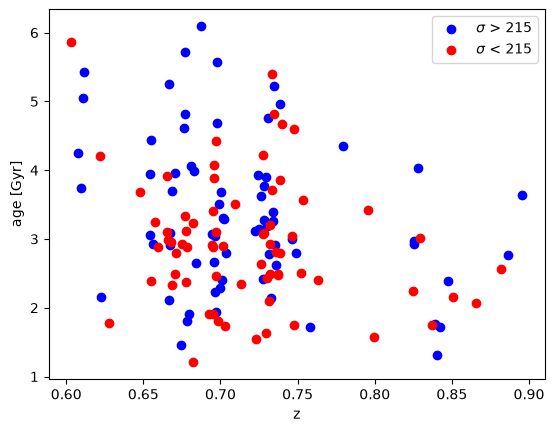

In [5]:
# Collapse repeat spectra to one row per galaxy. Age and z are object-level (identical
# across an object's spectra); only sigma is measured per spectrum, so average it.
# Dropping repeats instead (keep=False) discards 3 galaxies and leaves 137 objects.
galaxies = df.groupby('mms2013_id', as_index = False).agg(
    n_spectra = ('dr2_spect_id', 'size'),
    dr2_z_spec = ('dr2_z_spec', 'mean'),
    dr2_sigma_stars_prime_km_s = ('dr2_sigma_stars_prime_km_s', 'mean'),
    borghi_age_gyr = ('borghi_age_gyr', 'mean'),
)

high_disp = galaxies[galaxies['dr2_sigma_stars_prime_km_s'] > 215].copy()
low_disp = galaxies[galaxies['dr2_sigma_stars_prime_km_s'] <= 215].copy()

# Borghi 2022b Table 1: 140 galaxies total, 70 higher sigma*, 70 lower sigma*
print(f"objects {len(galaxies)} (paper 140) | high {len(high_disp)} (70) | low {len(low_disp)} (70)")

plt.scatter(high_disp['dr2_z_spec'], high_disp['borghi_age_gyr'], c='blue', label = r'$\sigma$ > 215' )
plt.scatter(low_disp['dr2_z_spec'], low_disp['borghi_age_gyr'], c='red', label = r'$\sigma$ < 215')
plt.xlabel('z')
plt.ylabel('age [Gyr]')
plt.legend()

- `pd.cut` assigns each galaxy a redshift bin
- `right=False` makes bins left-closed
- median, not mean, for bin redshift

In [6]:
# Edges reconstructed by fitting to the paper's Table 1, not explicitly published
high_z_edges = [0.6078, 0.6681, 0.7425, 0.8399, 0.8956]
low_z_edges = [0.6031, 0.6730, 0.7499, 0.8272, 0.8819]


high_disp['z_bin'] = pd.cut(high_disp['dr2_z_spec'], bins = high_z_edges, right = False, labels = ["1", "2", "3", "4"], include_lowest = True)

high_disp_bins = high_disp.groupby('z_bin', observed = False).agg({'mms2013_id' : 'count', 'dr2_z_spec': 'median', 'borghi_age_gyr': 'median'})

high_disp_bins

,mms2013_id,dr2_z_spec,borghi_age_gyr
z_bin,,,
1,13,0.654200,3.739
2,44,0.700761,3.279
3,8,0.802237,2.947
4,5,0.847300,2.390


- pairs alternate bins, i and i+2
- constant converts inverse Gyr to km/s/Mpc
- sign flips because age falls as redshift rises

In [7]:
low_disp['z_bin'] = pd.cut(low_disp['dr2_z_spec'], bins = low_z_edges, right = False, labels = ["1", "2", "3", "4"], include_lowest = True)

low_disp_bins = low_disp.groupby('z_bin', observed = False).agg({'mms2013_id' : 'count', 'dr2_z_spec': 'median', 'borghi_age_gyr': 'median'})

low_disp_bins

,mms2013_id,dr2_z_spec,borghi_age_gyr
z_bin,,,
1,14,0.662450,2.9695
2,45,0.722986,2.9190
3,6,0.779660,2.4560
4,5,0.850893,2.1500


- `scale='normal'` rescales NMAD to a standard deviation
- dividing by `sqrt(N)` gives the median's standard error

In [8]:
def H_from_bins(galaxies, bins_df, bin_1, bin_2): #bins_df is the binned dataframe you pass in, galaxies is full
    intermediate_z = (bins_df.loc[bin_1, "dr2_z_spec"] + bins_df.loc[bin_2, "dr2_z_spec"])/2

    delta_z = bins_df.loc[bin_1, "dr2_z_spec"] - bins_df.loc[bin_2, "dr2_z_spec"]

    delta_age = bins_df.loc[bin_1, "borghi_age_gyr"] - bins_df.loc[bin_2, "borghi_age_gyr"]

    H = (977.8*-1/(1+intermediate_z)*delta_z/delta_age)

    #Uncertaintly mainly from borghi_age_yr (SPD fitted), uncertainty in z is negligible

    age_err_1 = median_abs_deviation(galaxies.loc[galaxies["z_bin"] == bin_1, 'borghi_age_gyr'], scale = 'normal') / np.sqrt(bins_df.loc[bin_1, "mms2013_id"])

    age_err_2 = median_abs_deviation(galaxies.loc[galaxies["z_bin"] == bin_2, 'borghi_age_gyr'], scale = 'normal') / np.sqrt(bins_df.loc[bin_2, "mms2013_id"])

    sigma_H = H * np.hypot(age_err_1, age_err_2) / np.abs(delta_age)

    return intermediate_z, H, sigma_H, 

rows = [] # list will get turned into a dataframe

for bin_1, bin_2 in [("1","3"), ("2","4")]: # df indices were strings
    intermediate_z, H, sigma_H = H_from_bins(high_disp, high_disp_bins, bin_1, bin_2)
    rows.append({"bins": bin_1 + bin_2, "z_eff": intermediate_z, "H": H, "sigma_H": sigma_H}) # bin_1 + bin_2 is concatenated string, not addition

results_high_disp = pd.DataFrame(rows)

rows = []

for bin_1, bin_2 in [("1","3"), ("2","4")]: # df indices were strings
    intermediate_z, H, sigma_H = H_from_bins(low_disp, low_disp_bins, bin_1, bin_2)
    rows.append({"bins": bin_1 + bin_2, "z_eff": intermediate_z, "H": H, "sigma_H": sigma_H})

results_low_disp = pd.DataFrame(rows)

results_low_disp, results_high_disp

(  bins     z_eff           H    sigma_H
 0   13  0.721055  129.682475  99.080433
 1   24  0.786939   91.013648  34.424111,
   bins     z_eff           H    sigma_H
 0   13  0.728218  105.753579  62.122093
 1   24  0.774031   90.853239  47.544153)

In [9]:
# Combine all binned data for variance-weighted average

# ignore_index discards earlier indices to prevent duplicates
results = pd.concat([results_high_disp, results_low_disp], ignore_index=True)

w = 1 / results["sigma_H"] ** 2
# list of weights

H_joint = (w * results["H"]).sum() / w.sum()
# Weight is inverse of variance (inverse sigma squared)
# element wise multiplication

sigma_joint = np.sqrt(1 / w.sum())

#average all redshifts and assume combined H at one z
z_joint = results["z_eff"].mean()

joint = pd.DataFrame([{"H": H_joint, "sigma_H": sigma_joint, "z_eff": z_joint }])
# adding square brackets makes pandas read it as a row
# without square brackets it's read as a column
# scalars are treated as having 0 length and aren't a valid column

joint

,H,sigma_H,z_eff
0,95.680525,24.638858,0.752561


close reproduction - paper has H = 98.8 ± 24.8

I'm going to try and recreate the photo/spectroscopic classification of quiescent galaxies from borghi 2022 (Figure 1, page 4)

Things to note: Claude applied good quality spectra flags from Straatman 2018 and excluded LEGA-C data without COSMOS2015 photometry, cutting the total ~3000 DR2 galaxies to 1622 sources as mentioned in Borghi (claude cut to 1618, close enough)

In [10]:
from astropy.coordinates import SkyCoord
from astropy.table import Table

# Set data path relative to current working directory cwd
legac_path = Path.cwd() / '../data/raw/legac_dr2/legaCdr2.fits.gz'
cosmos_path = Path.cwd() / '../data/raw/cosmos2015/cosmos2015_legac_dr2_xmatch_1arcsec.fits'

# Table.read is astropy reader for FITS 
# Returns a Table object, similar to a dataframe
legac = Table.read(legac_path)
cosmos = Table.read(cosmos_path)


legac_coords = SkyCoord(legac['RAJ2000'], legac['DECJ2000'], unit = 'deg')
cosmos_coords = SkyCoord(cosmos['RAJ2000'], cosmos['DEJ2000'], unit = 'deg')

In [11]:
legac

OBJECT,SPECT_ID,RAJ2000,DECJ2000,z,Filename,SIGMA_STARS_PRIME,SIGMA_STARS_PRIME_err,SIGMA_GAS_PRIME,SIGMA_GAS_PRIME_err,LICK_CN1,LICK_CN1_err,LICK_CN2,LICK_CN2_err,LICK_CA4227,LICK_CA4227_err,LICK_G4300,LICK_G4300_err,LICK_FE4383,LICK_FE4383_err,LICK_CA4455,LICK_CA4455_err,LICK_FE4531,LICK_FE4531_err,LICK_C4668,LICK_C4668_err,LICK_HB,LICK_HB_err,LICK_HD_A,LICK_HD_A_err,LICK_HG_A,LICK_HG_A_err,LICK_HD_F,LICK_HD_F_err,LICK_HG_F,LICK_HG_F_err,LICK_D4000_N,LICK_D4000_N_err,Hd_flux,Hd_err,Hd_EW,Hd_EW_err,Hg_flux,Hg_err,Hg_EW,Hg_EW_err,Hb_flux,Hb_err,Hb_EW,Hb_EW_err,OII_3727_flux,OII_3727_err,OII_3727_EW,OII_3727_EW_err,OIII_4959_flux,OIII_4959_err,OIII_4959_EW,OIII_4959_EW_err,OIII_5007_flux,OIII_5007_err,OIII_5007_EW,OIII_5007_EW_err,f_ppxf,f_z,f_spec,f_primary,f_use,f_int,Tcor,SN,SN_RF_4000,SN_OBS_8030
,,deg,deg,,,km / s,km / s,km / s,km / s,Angstrom,Angstrom,Angstrom,Angstrom,Angstrom,Angstrom,Angstrom,Angstrom,Angstrom,Angstrom,Angstrom,Angstrom,Angstrom,Angstrom,Angstrom,Angstrom,Angstrom,Angstrom,Angstrom,Angstrom,Angstrom,Angstrom,Angstrom,Angstrom,Angstrom,Angstrom,Angstrom,Angstrom,1e-19 erg / (s cm2),1e-19 erg / (s cm2),Angstrom,Angstrom,1e-19 erg / (s cm2),1e-19 erg / (s cm2),Angstrom,Angstrom,1e-19 erg / (s cm2),1e-19 erg / (s cm2),Angstrom,Angstrom,1e-19 erg / (s cm2),1e-19 erg / (s cm2),Angstrom,Angstrom,1e-19 erg / (s cm2),1e-19 erg / (s cm2),Angstrom,Angstrom,1e-19 erg / (s cm2),1e-19 erg / (s cm2),Angstrom,Angstrom,,,,,,,,1 / pix,1 / pix,1 / pix
int32,bytes10,float64,float64,float32,bytes26,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,int16,int16,int16,int16,int16,float32,float32,float32,float32
126153,M1_126153,150.1446533203125,2.2785110473632812,0.6823,legac_M1_126153_v2.0.fits,115.0,13.8,--,--,-0.0025,0.0291,0.0141,0.0289,0.2442,0.4725,3.8049,0.9891,2.085,1.3747,0.3339,0.6492,1.5455,1.8289,3.4731,2.4907,1.8845,0.6129,1.0152,0.8314,-3.1083,1.0375,1.8253,0.6163,-0.9429,0.8968,1.5582,0.0375,--,6.939,--,0.241,--,10.37,--,0.318,--,11.543,--,0.28,--,--,--,--,--,10.028,--,0.25,--,7.552,--,0.19,0,0,0,1,1,0,45.7555,10.3,10.0,13.1
126275,M1_126275,150.30169677734375,2.278995990753174,0.9297,legac_M1_126275_v2.0.fits,225.0,11.0,--,--,0.047,0.0189,0.0829,0.0183,0.9876,0.2522,0.0,--,5.2542,1.5278,1.616,0.4032,--,--,--,--,--,--,-0.785,0.5535,-3.1334,1.0533,0.6782,0.4186,-0.1804,0.6671,1.7319,0.0269,--,22.73,--,0.326,--,22.636,--,0.306,--,--,--,--,--,13.354,--,0.338,--,--,--,--,--,--,--,--,0,0,0,1,1,0,5.7628,10.6,17.4,18.0
126578,M1_126578,150.09805297851562,2.281367063522339,0.7504,legac_M1_126578_v2.0.fits,169.4,13.1,--,--,-0.0108,0.0263,0.0251,0.0261,0.7262,0.432,4.0462,0.6626,2.4486,0.9876,1.7628,0.6226,2.4939,1.0376,2.8898,0.9662,0.8255,0.5292,0.0375,0.5814,-1.4506,0.7964,0.8444,0.4174,0.301,0.8167,--,--,--,21.538,--,0.206,--,65.312,--,0.568,--,52.31,--,0.335,--,--,--,--,--,33.99,--,0.224,--,50.368,--,0.336,0,0,0,1,1,0,3.3621,15.1,12.3,20.9
126585,M1_126585,150.32394409179688,2.282331943511963,0.9822,legac_M1_126585_v2.0.fits,308.0,12.1,--,--,--,--,--,--,0.5761,0.2213,--,--,--,--,--,--,--,--,--,--,--,--,0.6179,0.2635,--,--,1.2991,0.1834,--,--,1.6783,0.0244,--,16.306,--,0.138,--,--,--,--,--,--,--,--,--,20.114,--,0.286,--,--,--,--,--,--,--,--,0,0,0,1,1,0,3.3715,13.6,25.0,25.3
126753,M1_126753,150.0906524658203,2.2851579189300537,0.75,legac_M1_126753_v2.0.fits,262.0,41.3,395.9,73.6,-0.1548,0.1474,-0.1004,0.145,3.362,1.425,2.4958,4.3905,9.2951,3.7136,1.6592,3.3371,7.6573,4.4511,2.0511,3.9539,3.0719,3.4428,4.7653,2.8822,4.7079,4.4954,5.1788,2.0278,8.4927,3.8452,--,--,44.588,19.901,-2.996,1.34,91.892,55.234,-4.992,3.004,148.1

In [12]:
# match to catalog is a method for a Skycoord object
# syntax: coords_1.match to (coords 2) -> coords_1 is baseline
# returns tuple of arrays: index (starting from 0, for cosmos), angular sep (with units), and 3D distance - discarded here
index, sep, _ = legac_coords.match_to_catalog_sky(cosmos_coords)

matched = sep < 1 * u.arcsec # boolean mask on array

legac_matched = legac[matched]
cosmos_matched = cosmos[index][matched]
# calling cosmos index reindexes, first matched column is 0 -> matches legac

legac_matched["NUVMag"] = cosmos_matched["NUVMag"]
legac_matched["RMag"] = cosmos_matched["RMag"]
legac_matched["JMag"] = cosmos_matched["JMag"]
# create new columns in the table and give the cosmos values
# many of the COSMOS parameters: RMag, Jmag, etc are interpolated SED fits -> they aren't actual data

parent = legac_matched.to_pandas()

In [13]:
# apply good spectra flags
good = (parent['f_ppxf'] == 0) & (parent['f_z'] == 0) & (parent['f_int'] == 0) & (parent['SN'] > 0)
# f_ppxf: pPXF continuum fit reliable
# f_z:    spectroscopic redshift secure
# f_int:  no interloper contaminating the slit
# SN:     continuum S/N measured (not null)

valid = (parent[['NUVMag', 'RMag', 'JMag']] > -40).all(axis = 1)
# -99.99 is the COSMOS2015 null for absolute magnitudes
# there were still some outliers at -40, so tighten past -99
# instead of masking by array we can create a 3-column mask dataframe
# .all(axis = 1) then collapses the DF into a Series of indices
# .all() -> only if all 3 columns are true
parent = parent[good & valid]


In [14]:
# Apply the NUVrJ criteria from Ilbert et al 2013
# NUVMag - Rmag has to be larger than Rmag - Jmag
# Extinction means both will be large
# But quiescence means only the first is large, not the second
Ilbert_mask = (parent['NUVMag'] - parent['RMag'] > 3 * (parent['RMag'] - parent['JMag']) + 1) & (parent['NUVMag'] - parent['RMag'] > 3.1 )
photometric_passive = parent[Ilbert_mask]
# verified length 666, ~668 in paper

Adding NUVrJ selection to plot

Implement the O[II] selection

In [15]:
ew = photometric_passive['OII_3727_EW']
# effective width column
# ew is negative for LEGAC
spectrophotometric_passive = photometric_passive[(ew > - 5) | ew.isna()]
# | is elementwise OR - used for a series
# so keep ew small or if ew is NaN (no measurement)


In [16]:
# Cut high S/N [OII] / O[III] EW

sn_o2 = (spectrophotometric_passive['OII_3727_EW']  / spectrophotometric_passive['OII_3727_EW_err']).abs()
sn_o3 = (spectrophotometric_passive['OIII_5007_EW'] / spectrophotometric_passive['OIII_5007_EW_err']).abs()
bona_fide_passive = spectrophotometric_passive[~((sn_o2 >= 3) | (sn_o3 >= 3))]
#~ is elementwise flip -> turns false into true. NaN evaluates to false; NaN >= 3 is false

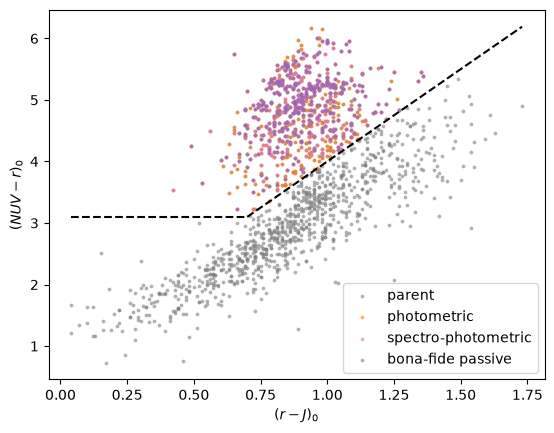

In [17]:
rJ = parent['RMag'] - parent['JMag'] # x axis
NUVr = parent['NUVMag'] - parent['RMag'] # y axis

fig, ax = plt.subplots()

layers = [(parent, 'grey', 3, 'parent'), (photometric_passive, 'tab:orange', 3, 'photometric'), (spectrophotometric_passive, 'tab:pink', 3, 'spectro-photometric'), (bona_fide_passive, 'tab:purple', 3, 'bona-fide passive')]

for sample, color, size, label in layers:
    ax.scatter(rJ[sample.index], NUVr[sample.index], s = size, alpha = 0.5, c = color, label = label)

# calling ax.scatter instead of plt.scatter explicitly assigns it to plot on that ax panel
# s: point size, alpha: point opacity

x = np.linspace(0.7, rJ.max(), 2)
# lin space -> linearly spaced
# create two points for the sloped part 
ax.plot(x, 3*x + 1, 'k', linestyle = '--')
ax.hlines(3.1, rJ.min(), 0.7, 'k', linestyle = '--')

ax.set_xlabel('$(r - J)_0$')
ax.set_ylabel('$(NUV - r)_0$')
ax.legend()

# cell containing plt.subplots autorenders
# later cells need to manually call fig

/Users/liuhao/Downloads/Astro project/.venv/lib/python3.14/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


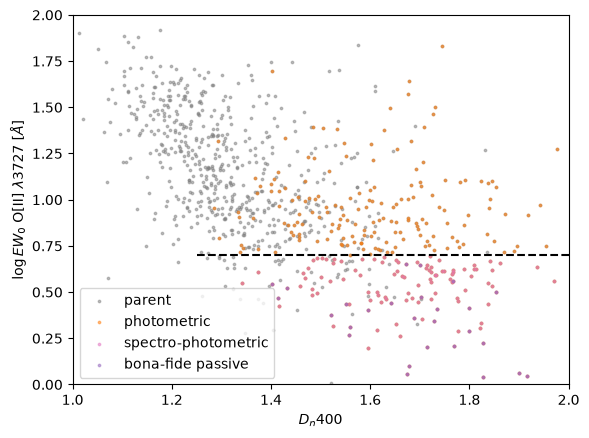

In [18]:
Dn_4000 = parent["LICK_D4000_N"] # x axis
ew = np.log10(np.abs(parent["OII_3727_EW"])) # y axis
# LEGA-C signs EW as negative

fig, ax = plt.subplots()

for sample, color, size, label in layers:
    ax.scatter(Dn_4000[sample.index], ew[sample.index], s = size, alpha = 0.5, c = color, label = label)

plt.ylim(0.0, 2.0)
plt.xlim(1.0, 2.0)
ax.hlines(np.log10(5), 1.25, ax.get_xlim()[1], 'k', linestyle = '--')
# don't know what the cutoff criteria for their hline is, just set it to 1.25

ax.set_xlabel('$D_n400$')
ax.set_ylabel(r'$\log EW_0$ O[II] $\lambda 3727$ [$\AA$]')
# keep separate latex delimiters so the text isn't italicised
ax.legend()

## 1. Load LEGA-C spectra

- one FITS file per spectrum, named by the `Filename` column
- the table holds a single row; each cell is a whole array
- `QUAL = 1` marks a pixel to discard, and sets `ERR = 0`

In [19]:
from astropy.io import fits

spectra_dir = Path.cwd() / '../data/raw/legac_dr2/sp'
# spectra samples for each galaxy, restored by scripts/download_legac_dr2_spectra.py


def load_spectrum(filename):
    """Read one LEGA-C DR2 1D spectrum.

    Returns wave, flux, err, good.
    wave is in angstrom, measured in air and topocentric (no barycentric correction).
    flux and err are in 1e-19 erg s-1 cm-2 angstrom-1.
    good is False wherever the pipeline flagged the pixel.
    """
    if isinstance(filename, bytes):
        filename = filename.decode()
        # astropy leaves FITS string columns as bytes after .to_pandas()

    with fits.open(spectra_dir / filename) as hdulist:
        spectrum = hdulist[1].data

    wave, flux, err, qual = (spectrum[c][0] for c in ('WAVE', 'FLUX', 'ERR', 'QUAL'))
    # [0] takes the single table row, whose four cells each hold the full 6166 pixels
    # without it every array comes back with a redundant leading axis, shape (1, 6166)

    good = (qual == 0) & (err > 0) & np.isfinite(flux)
    # ERR = 0 means discard the pixel, not that the error is small
    # keeping the flag rather than pre-filtering means nothing is dropped silently
    return wave, flux, err, good

### 1.1 Demonstration galaxy: M1_207825

- flagged pixels still contain recorded flux, but it is unreliable
- causes include detector defects, cosmic rays, or poor sky subtraction
- `QUAL = 1` and `ERR = 0` mean discard, not zero flux

M1_207825  z = 0.6968
median S/N per pixel: measured 70.1, catalogue SN 70.0
covered 6283-8735 angstrom, flagged 2092 of 6166 pixels


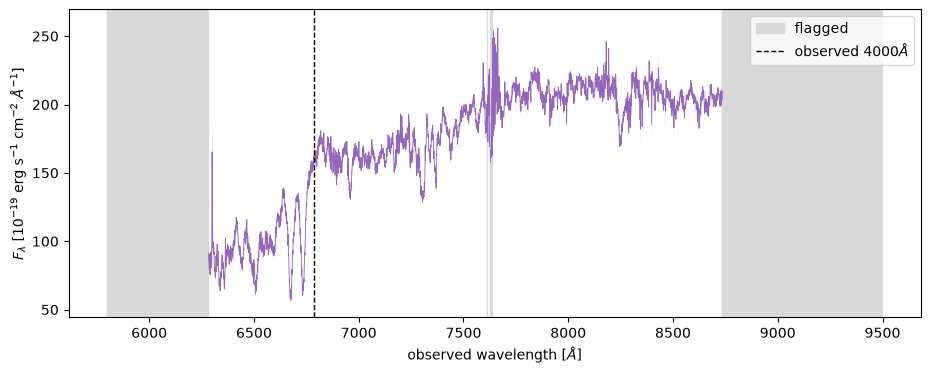

In [20]:
for _, row in bona_fide_passive.sort_values('SN', ascending = False).iterrows():
    wave, flux, err, good = load_spectrum(row['Filename'])
    if wave[good].min() < 4000 * (1 + row['z']) < wave[good].max():
        best = row
        break
# take the highest-SN spectrum that actually covers its own 4000 angstrom break
# coverage differs from spectrum to spectrum, so test it against this file's good
# pixels rather than the nominal 6332-8900 angstrom range in the release notes

fig, ax = plt.subplots(figsize = (11, 4))

ax.fill_between(wave, 0, 1, where = ~good, transform = ax.get_xaxis_transform(),
                color = '0.85', step = 'mid', label = 'flagged')
# get_xaxis_transform reads y in axes units (0 to 1) and x in data units,
# so the shading spans the full height whatever the flux range turns out to be

ax.plot(wave, np.where(good, flux, np.nan), lw = 0.6, c = 'tab:purple')
# NaN breaks the line at flagged pixels instead of interpolating across them
ax.fill_between(wave, np.where(good, flux - err, np.nan), np.where(good, flux + err, np.nan),
                color = 'tab:purple', alpha = 0.3, lw = 0)

ax.axvline(4000 * (1 + best['z']), c = 'k', ls = '--', lw = 1, label = r'observed $4000\AA$')

ax.set_xlabel(r'observed wavelength [$\AA$]')
ax.set_ylabel(r'$F_\lambda$ [$10^{-19}$ erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$]')
ax.legend()

sn_measured = np.median(flux[good] / err[good])
print(f"{best['SPECT_ID'].decode()}  z = {best['z']:.4f}")
print(f"median S/N per pixel: measured {sn_measured:.1f}, catalogue SN {best['SN']:.1f}")
print(f"covered {wave[good].min():.0f}-{wave[good].max():.0f} angstrom, "
      f"flagged {(~good).sum()} of {good.size} pixels")

## 2. Convert the LEGA-C spectrum into a Prospector observation

- reload the chosen galaxy spectra
- convert LEGA-C air wavelengths to FSPS vacuum wavelengths
- convert flux and uncertainty from `F_lambda` to maggies
- mask bad pixels, emission lines, and atmospheric absorption
- `fix_obs` packages the arrays into Prospector's observation dictionary
- `TOT_FLUX = False`, the spectrum misses some galaxy light

In [ ]:
from astropy.constants import c as c_light
from specutils.utils.wcs_utils import air_to_vac
from prospect.utils.obsutils import fix_obs

C_KMS = c_light.to_value(u.km / u.s)
DR2_FLUX_UNIT = 1e-19 * u.erg / u.s / u.cm**2 / u.AA   # LEGA-C DR2 flux scale
AB_ZERO_POINT = 3631 * u.Jy                            # 1 maggie = f_nu / 3631 Jy

galaxy = best
# M1_207825, z = 0.6968, sigma* = 228.9 km/s. The same object notebook 02 fits with
# Lick indices, so its published and Lick-derived ages are the comparison numbers

wave_air, flux_dr2, err_dr2, good = load_spectrum(galaxy['Filename'])

wave = air_to_vac(wave_air * u.AA).to_value(u.AA)
# measured: FSPS is a vacuum wavelength.
# light is slower in air, but frequency is fixed, so wavelength is slightly shorter
# LEGA-C doesn't correct for this


def to_maggies(f_lambda, wave_angstrom):
    """DR2 F_lambda -> maggies, the flux unit Prospector's likelihood assumes."""
    f_nu = (f_lambda * DR2_FLUX_UNIT) * (wave_angstrom * u.AA) ** 2 / c_light
    return (f_nu / AB_ZERO_POINT).to_value(u.dimensionless_unscaled)


spectrum = to_maggies(flux_dr2, wave)
uncertainty = to_maggies(err_dr2, wave)

z = float(galaxy['z'])
sigma_star = float(galaxy['SIGMA_STARS_PRIME'])

REST_EMISSION_LINES = [3726.0, 3728.8, 4861.3, 4958.9, 5006.8]
# [OII] doublet, H-beta, [OIII] doublet: the lines that survive the passive cut
TELLURIC_BANDS = [(7590.0, 7660.0)]
# Earth's atmosphere creates telluric absorption, unrelated to the galaxy
# O2 A-band; QUAL flags it here but not every spectrum

mask = good.copy()
for rest_wavelength in REST_EMISSION_LINES:
    observed = rest_wavelength * (1 + z)
    mask &= np.abs(wave - observed) > 3 * sigma_star / C_KMS * observed
    # +-3 sigma* around where the line actually lands, in the observed frame
for low, high in TELLURIC_BANDS:
    mask &= (wave < low) | (wave > high)

obs = fix_obs({'wavelength': wave, 'spectrum': spectrum, 'unc': uncertainty, 'mask': mask,
               'filters': None, 'maggies': None, 'maggies_unc': None})
# filters/maggies None means spectroscopy only; fix_obs fills in the keys Prospector
# expects and counts the unmasked pixels into obs['ndof']

print(f"{galaxy['SPECT_ID'].decode()}  z = {z:.4f}  sigma* = {sigma_star:.1f} km/s")
print(f"pixels: {good.sum()} good -> {mask.sum()} after line and telluric masking")
print(f"median flux {np.median(spectrum[mask]):.3e} maggies "
      f"({-2.5 * np.log10(np.median(spectrum[mask])):.2f} AB per pixel)")
print(f"median S/N {np.median(spectrum[mask] / uncertainty[mask]):.1f} "
      f"(unit-independent, so it must still equal the catalogue {galaxy['SN']:.0f})")

M1_207825  z = 0.6968  sigma* = 228.9 km/s
pixels: 4074 good -> 3722 after line and telluric masking
median flux 9.231e-09 maggies (20.09 AB per pixel)
median S/N 69.9 (unit-independent, so it must still equal the catalogue 70)


## 3. Define the Prospector SSP model and likelihood

- `zcontinuous=1` builds SSPs at every library metallicity once, then interpolates
- `min_wave_smooth`/`max_wave_smooth` are in the **observed** frame
- restricting them to the fitted range is a ~1800x speedup, bit-identical output
- `dust2` fixed: a dust screen and a calibration polynomial are degenerate
- no age-of-universe prior, matching Borghi's model-independent stance

In [22]:
from prospect.models import priors
from prospect.models.sedmodel import PolySpecModel
from prospect.models.templates import TemplateLibrary
from prospect.sources import CSPSpecBasis

sps = CSPSpecBasis(zcontinuous=1)
# zcontinuous=1 makes FSPS compute SSPs at all 12 library metallicities once - about
# 30 s on the first call and 30 s again on the first logzsol change - and interpolate
# for free after that. zcontinuous=0 recomputes on every metallicity change, ~14 s each

SMOOTH_WINDOW = (6000.0, 9000.0)
# observed frame, bracketing this spectrum's 6283-8735 angstrom coverage. Prospector
# smooths on the observed grid, and without a window smooth_vel_fft resamples the whole
# FSPS array - 91 angstrom to 1e8 angstrom - onto a uniform log grid every single call.
# Windowing it is 2830 ms -> 1.6 ms per likelihood with a bit-identical spectrum

model_params = TemplateLibrary['ssp']                        # delta-function SFH
model_params.update(TemplateLibrary['spectral_smoothing'])   # sigma_smooth, in km/s
model_params.update(TemplateLibrary['optimize_speccal'])     # polynomial calibration

model_params['zred']['init'] = z
model_params['imf_type']['init'] = 2
# Kroupa. alpha-MILES in notebook 02 used bimodal 1.3 - a real difference, not a match

model_params['dust2']['isfree'] = False
model_params['dust2']['init'] = 0.0
# a dust screen and the calibration polynomial are both smooth multiplicative functions
# of wavelength, so they are degenerate with spectroscopy alone. The Lick fit made the
# same assumption implicitly: an index is measured against its own local pseudo-continuum

model_params['mass']['isfree'] = False
model_params['mass']['init'] = 1e10
# the polynomial rescales the model at every likelihood call, so mass is exactly
# degenerate with it and carries no information in a spectroscopy-only fit. Left free it
# was by far the worst-mixing parameter. No stellar mass is claimed from this fit

model_params['tage']['prior'] = priors.TopHat(mini=0.1, maxi=13.7)
# deliberately no age-of-universe prior. Borghi's measurement is model-independent, so
# importing a cosmology here would contaminate it. Whether the posterior runs past the
# age of the universe at this redshift is reported below rather than forbidden
model_params['logzsol']['prior'] = priors.TopHat(mini=-1.98, maxi=0.5)
# +0.5 is the top of the FSPS/MIST zlegend, not the 0.19 of prospector's default prior.
# Caveat: MILES has very few stars above [Fe/H] ~ +0.2, so the empirical library is
# extrapolating up there. MIST is also scaled-solar, so unlike the alpha-MILES fit in
# notebook 02 there is no [alpha/Fe] axis at all
model_params['sigma_smooth']['prior'] = priors.TopHat(mini=50.0, maxi=400.0)
# the template default stops at 300 km/s, below this galaxy's expected line width

model_params['polyorder']['init'] = 10
model_params['fftsmooth'] = {'N': 1, 'isfree': False, 'init': True}
model_params['min_wave_smooth'] = {
    'N': 1, 'isfree': False, 'init': SMOOTH_WINDOW[0],
}
model_params['max_wave_smooth'] = {
    'N': 1, 'isfree': False, 'init': SMOOTH_WINDOW[1],
}

model = PolySpecModel(model_params)
print(model)

:::::::
<class 'prospect.models.sedmodel.PolySpecModel'>

Free Parameters: (name: prior) 
-----------
  logzsol: <class 'prospect.models.priors.TopHat'>(mini=-1.98,maxi=0.5)
  tage: <class 'prospect.models.priors.TopHat'>(mini=0.1,maxi=13.7)
  sigma_smooth: <class 'prospect.models.priors.TopHat'>(mini=50.0,maxi=400.0)

Fixed Parameters: (name: value [, depends_on]) 
-----------
  zred: [0.69679999] 
  mass: [1.e+10] 
  dust2: [0.] 
  sfh: [0] 
  imf_type: [2] 
  dust_type: [0] 
  smoothtype: ['vel'] 
  fftsmooth: [ True] 
  polyorder: [10] 
  poly_regularization: [0.] 
  spec_norm: [1.] 
  min_wave_smooth: [6000.] 
  max_wave_smooth: [9000.] 


## 4. Check the LSF and Borghi/Lick reference spectrum

- predict the reference spectrum before fitting Prospector
- compare expected and fitted velocity broadening consistently

rest-frame midpoint 4382 A
sigma_MILES 72.9 | sigma_inst 50.9 | sigma* 228.9  ->  expect sigma_smooth ~ 223 km/s
starting chi2/pixel = 3.48 before any fitting


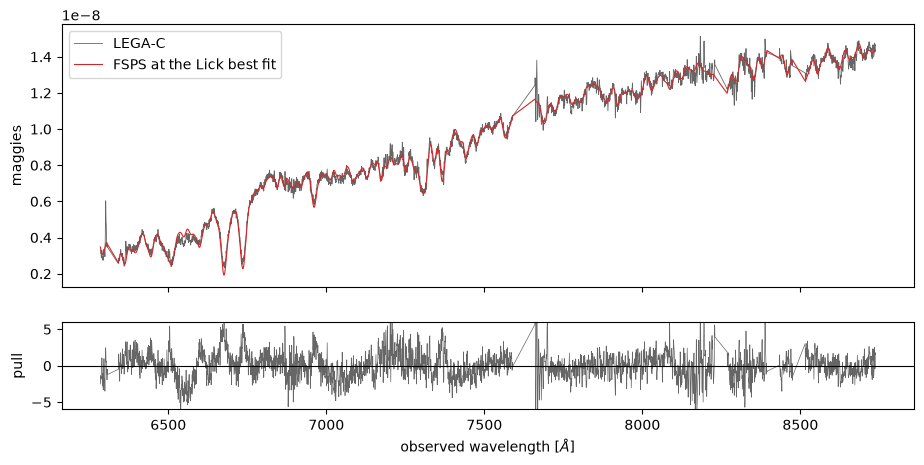

In [23]:
MILES_FWHM_AA = 2.51          # FSPS's MILES library resolution, constant in rest lambda
LEGAC_R = 2500.0              # SPEC_RES from the spectrum header. Notebook 02 used 3500
SIGMA_TO_FWHM = 2.355

rest_mid = np.median(wave[mask]) / (1 + z)
sigma_miles = (MILES_FWHM_AA / SIGMA_TO_FWHM) / rest_mid * C_KMS
sigma_instrument = C_KMS / (SIGMA_TO_FWHM * LEGAC_R)
sigma_expected = np.sqrt(sigma_star**2 + sigma_instrument**2 - sigma_miles**2)
# MILES' own width is already in the model, so sigma_smooth is the *extra* broadening.
# This is the check the whole forward model lives or dies on: units, redshifting, the
# wavelength convention and the LSF all have to be right for it to come back near this

print(f'rest-frame midpoint {rest_mid:.0f} A')
print(f'sigma_MILES {sigma_miles:.1f} | sigma_inst {sigma_instrument:.1f} | '
      f'sigma* {sigma_star:.1f}  ->  expect sigma_smooth ~ {sigma_expected:.0f} km/s')

theta_lick = model.theta.copy()
for name, value in [('tage', 2.0), ('logzsol', 0.15), ('sigma_smooth', sigma_expected)]:
    theta_lick[model.theta_index[name]] = value
# notebook 02's best-fitting native-grid model for this galaxy, as a starting guess

predicted, _, _ = model.predict(theta_lick, obs=obs, sps=sps)

fig, (ax, axr) = plt.subplots(2, 1, figsize=(11, 5), sharex=True,
                              gridspec_kw={'height_ratios': [3, 1]})
ax.plot(wave[mask], spectrum[mask], lw=0.6, c='0.4', label='LEGA-C')
ax.plot(wave[mask], predicted[mask], lw=0.8, c='tab:red', label='FSPS at the Lick best fit')
ax.set_ylabel('maggies')
ax.legend()

axr.plot(wave[mask], (spectrum[mask] - predicted[mask]) / uncertainty[mask], lw=0.5, c='0.4')
axr.axhline(0, c='k', lw=0.8)
axr.set_ylim(-6, 6)
axr.set_xlabel(r'observed wavelength [$\AA$]')
axr.set_ylabel('pull')

chi2_start = np.sum(((spectrum[mask] - predicted[mask]) / uncertainty[mask]) ** 2)
print(f'starting chi2/pixel = {chi2_start / mask.sum():.2f} before any fitting')

## 5. Run the Prospector SSP fit: M1_207825

- optimize and sample age, metallicity, and broadening
- fixed seed keeps the maximum-posterior fit reproducible

In [24]:
import time

from prospect.fitting import fit_model

FIT_SEED = 20260806
np.random.seed(FIT_SEED)
# prospector initialises the walker ball from numpy's legacy global state, so seeding
# it here is what makes this run reproducible

t0 = time.perf_counter()
output = fit_model(
    obs, model, sps,
    optimize=True, emcee=True, dynesty=False,
    min_method='powell', nmin=2,
    nwalkers=32, nburn=[200, 400, 800], niter=3000,
    initial_disp=0.1,
)
# nburn is a list of burn-in rounds; after each one the walker ball is re-centred on the
# best walker, which is how prospector unsticks walkers. Only the niter production
# samples come back in the sampler

sampler = output['sampling'][0]
print(f"optimize {output['optimization'][1]:.0f} s | "
      f"sample {output['sampling'][1]:.0f} s | "
      f"total {time.perf_counter() - t0:.0f} s")
print('chain', sampler.chain.shape)

/Users/liuhao/Downloads/Astro project/.venv/lib/python3.14/site-packages/prospect/models/priors.py:125: RuntimeWarning: divide by zero encountered in log
  lnp = np.log(p)
/Users/liuhao/Downloads/Astro project/.venv/lib/python3.14/site-packages/scipy/optimize/_optimize.py:3049: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom


number of walkers=32
done burn #0 (200 iterations)
done burn #1 (400 iterations)
done burn #2 (800 iterations)
number of walkers=32
starting production
done production
optimize 56 s | sample 222 s | total 278 s
chain (32, 3000, 3)


reduced chi2 = 3.23 over 3722 pixels (Lick indices gave 18.22 over 10)
age  = 1.44 +0.02 -0.02 Gyr  (Prospector)
       1.92 +0.19 -0.13 Gyr        (notebook 02, alpha-MILES Lick grid)
       1.94 Gyr                    (Borghi et al. 2022, published)
age of universe at z = 0.6968 is 7.18 Gyr (no prior imposed; posterior does not reach it)
sigma_smooth = 255 km/s against the 223 km/s predicted from sigma*, R and MILES


,parameter,median,minus,plus,tau,n_tau
0,logzsol,0.372704,0.010022,0.008925,37.067200,80.934087
1,tage,1.436710,0.015983,0.017874,41.807964,71.756663
2,sigma_smooth,255.177784,0.860505,1.007241,37.611111,79.763664


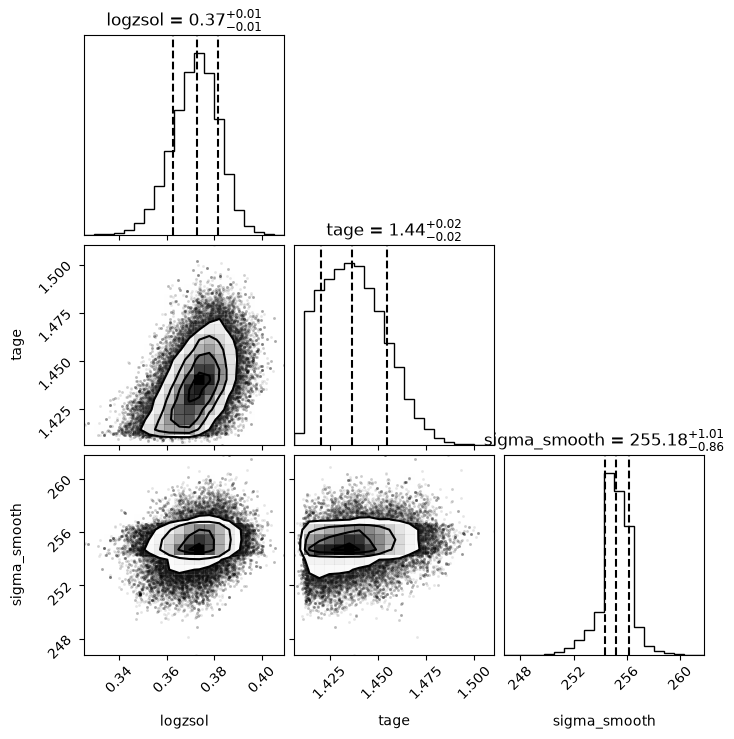

In [25]:
import emcee

chain = sampler.get_chain(flat=True)
tau = emcee.autocorr.integrated_time(sampler.get_chain(), tol=0)
q16, q50, q84 = np.percentile(chain, [16, 50, 84], axis=0)

posterior = pd.DataFrame({
    'parameter': model.free_params,
    'median': q50,
    'minus': q50 - q16,
    'plus': q84 - q50,
    'tau': tau,
    'n_tau': sampler.chain.shape[1] / tau,
})

best_walker = np.unravel_index(np.argmax(sampler.lnprobability), sampler.lnprobability.shape)
theta_best = sampler.chain[best_walker]
model_best, _, _ = model.predict(theta_best, obs=obs, sps=sps)
chi2_best = np.sum(((spectrum[mask] - model_best[mask]) / uncertainty[mask]) ** 2)
dof = mask.sum() - len(model.free_params) - (model_params['polyorder']['init'] + 1)
# the calibration polynomial is solved analytically at every likelihood call, so its
# coefficients still cost degrees of freedom even though they are never sampled

age = posterior.set_index('parameter').loc['tage']
t_universe = FlatLambdaCDM(H0=70, Om0=0.3).age(z).to_value(u.Gyr)

print(f'reduced chi2 = {chi2_best / dof:.2f} over {mask.sum()} pixels '
      f'(Lick indices gave 18.22 over 10)')
print(f'age  = {age["median"]:.2f} +{age["plus"]:.2f} -{age["minus"]:.2f} Gyr  (Prospector)')
print('       1.92 +0.19 -0.13 Gyr        (notebook 02, alpha-MILES Lick grid)')
print('       1.94 Gyr                    (Borghi et al. 2022, published)')
print(f'age of universe at z = {z:.4f} is {t_universe:.2f} Gyr '
      f'(no prior imposed; posterior {"does" if q84[model.theta_index["tage"]] > t_universe else "does not"} '
      f'reach it)')
print(f'sigma_smooth = {posterior.set_index("parameter").loc["sigma_smooth", "median"]:.0f} km/s '
      f'against the {sigma_expected:.0f} km/s predicted from sigma*, R and MILES')

corner.corner(chain, labels=model.free_params, quantiles=[0.16, 0.5, 0.84],
              show_titles=True, title_fmt='.2f')
posterior

## 6. Inspect the Prospector best-fit spectrum

- compare LEGA-C pixels directly with Prospector's fitted spectrum
- grey pixels are excluded from the likelihood
- shaded regions locate the dominant age-sensitive mismatches

/var/folders/x8/n5px4tbj1vb_8nwzfzd674hm0000gp/T/ipykernel_14382/2201238505.py:14: RuntimeWarning: divide by zero encountered in divide
  fitted_pixels, (spectrum - model_best) / uncertainty, np.nan


Text(0.5, 0, 'rest-frame wavelength [$\\AA$]')

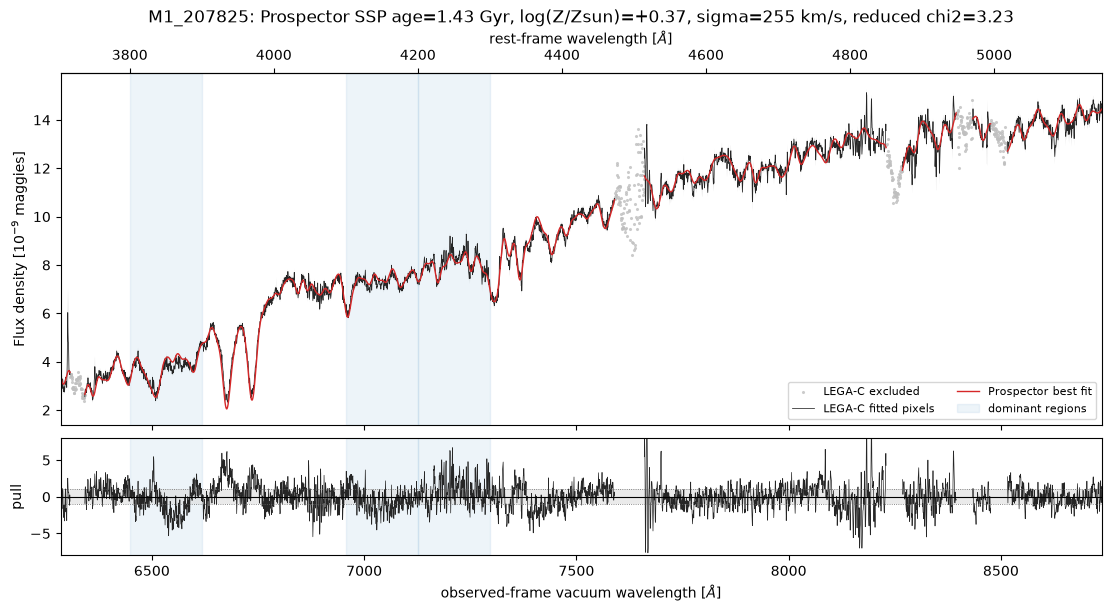

In [26]:
assert galaxy['SPECT_ID'].decode() == 'M1_207825'
assert wave.shape == spectrum.shape == uncertainty.shape == model_best.shape == mask.shape
assert mask.dtype == bool and np.array_equal(obs['mask'], mask)
assert np.allclose(obs['spectrum'], spectrum, equal_nan=True)
assert np.allclose(obs['unc'], uncertainty, equal_nan=True)

plot_scale = 1e9
fitted_pixels = mask & np.isfinite(spectrum) & np.isfinite(model_best)
excluded_pixels = good & ~mask & np.isfinite(spectrum)
fitted_data = np.where(fitted_pixels, spectrum * plot_scale, np.nan)
fitted_model = np.where(fitted_pixels, model_best * plot_scale, np.nan)
fitted_uncertainty = np.where(fitted_pixels, uncertainty * plot_scale, np.nan)
fit_pull = np.where(
    fitted_pixels, (spectrum - model_best) / uncertainty, np.nan
)

best_parameters = dict(zip(model.free_params, theta_best))
influential_regions = [
    (3800.0, 3900.0, 'Balmer/CN3883/H8'),
    (4100.0, 4200.0, 'Hdelta/CN/Fe'),
    (4200.0, 4300.0, 'Ca4227/G4300'),
]

fig, (ax, ax_pull) = plt.subplots(
    2, 1, figsize=(11, 6), sharex=True,
    gridspec_kw={'height_ratios': [3, 1]}, constrained_layout=True,
)

ax.scatter(
    wave[excluded_pixels], spectrum[excluded_pixels] * plot_scale,
    s=5, color='0.75', alpha=0.8, linewidths=0, label='LEGA-C excluded',
)
ax.fill_between(
    wave, fitted_data - fitted_uncertainty, fitted_data + fitted_uncertainty,
    color='0.5', alpha=0.18, linewidth=0,
)
ax.plot(wave, fitted_data, color='0.15', linewidth=0.55, label='LEGA-C fitted pixels')
ax.plot(wave, fitted_model, color='tab:red', linewidth=1.0, label='Prospector best fit')

for region_index, (low_rest, high_rest, label) in enumerate(influential_regions):
    low_observed, high_observed = np.array([low_rest, high_rest]) * (1 + z)
    for axis in (ax, ax_pull):
        axis.axvspan(
            low_observed, high_observed, color='tab:blue', alpha=0.08,
            label='dominant regions' if axis is ax and region_index == 0 else None,
        )

ax.set_ylabel(r'Flux density [$10^{-9}$ maggies]')
ax.legend(loc='best', ncol=2, fontsize=8)
ax.set_title(
    f"M1_207825: Prospector SSP age={best_parameters['tage']:.2f} Gyr, "
    f"log(Z/Zsun)={best_parameters['logzsol']:+.2f}, "
    f"sigma={best_parameters['sigma_smooth']:.0f} km/s, "
    f"reduced chi2={chi2_best / dof:.2f}"
)

ax_pull.axhspan(-1, 1, color='0.85', alpha=0.55, linewidth=0)
ax_pull.plot(wave, fit_pull, color='0.15', linewidth=0.5)
ax_pull.axhline(0, color='k', linewidth=0.8)
ax_pull.axhline(1, color='0.4', linewidth=0.6, linestyle=':')
ax_pull.axhline(-1, color='0.4', linewidth=0.6, linestyle=':')
ax_pull.set_ylim(-8, 8)
ax_pull.set_ylabel('pull')
ax_pull.set_xlabel(r'observed-frame vacuum wavelength [$\AA$]')
ax_pull.set_xlim(wave[good].min(), wave[good].max())

secondary_axis = ax.secondary_xaxis(
    'top', functions=(lambda observed: observed / (1 + z),
                      lambda rest: rest * (1 + z)),
)
secondary_axis.set_xlabel(r'rest-frame wavelength [$\AA$]')

## 7. Validate the fitting machinery with synthetic recovery

- refit a spectrum the model can produce exactly, on the same grid and errors
- separates "the sampler converged" from "the forward model is right"
- a biased `sigma_smooth` here means a bug; an unbiased one blames the data-model mismatch

In [27]:
truth = {'logzsol': -0.10, 'tage': 2.50, 'sigma_smooth': 200.0}

theta_true = model.theta.copy()
for name, value in truth.items():
    theta_true[model.theta_index[name]] = value

model_true, _, _ = model.predict(theta_true, obs=obs, sps=sps)
synthetic = model_true + np.random.default_rng(FIT_SEED).normal(0.0, uncertainty)
# same wavelength grid, same mask, same per-pixel errors as the real spectrum, so the
# only thing that has changed is that the truth is now inside the model family

obs_synth = fix_obs({
    'wavelength': wave, 'spectrum': synthetic, 'unc': uncertainty, 'mask': mask,
    'filters': None, 'maggies': None, 'maggies_unc': None,
})

np.random.seed(FIT_SEED)
out_synth = fit_model(obs_synth, model, sps, optimize=True, emcee=True, dynesty=False,
                      min_method='powell', nmin=2,
                      nwalkers=32, nburn=[200, 400], niter=1500, initial_disp=0.1)

chain_synth = out_synth['sampling'][0].get_chain(flat=True)
s16, s50, s84 = np.percentile(chain_synth, [16, 50, 84], axis=0)

recovery = pd.DataFrame({
    'parameter': model.free_params,
    'truth': [truth[name] for name in model.free_params],
    'recovered': s50,
    'minus': s50 - s16,
    'plus': s84 - s50,
})
recovery['pull'] = np.where(
    recovery['recovered'] > recovery['truth'],
    (recovery['recovered'] - recovery['truth']) / recovery['minus'],
    (recovery['recovered'] - recovery['truth']) / recovery['plus'],
)
# pull in units of the posterior width on the side facing the truth

theta_synth = np.array([recovery.set_index('parameter').loc[n, 'recovered']
                        for n in model.free_params])
fit_synth, _, _ = model.predict(theta_synth, obs=obs_synth, sps=sps)
chi2_synth = np.sum(((synthetic[mask] - fit_synth[mask]) / uncertainty[mask]) ** 2)

print(f'synthetic chi2/pixel = {chi2_synth / mask.sum():.2f} (must be ~1 by construction)')
print(f'real spectrum        = {chi2_best / dof:.2f}')
recovery

/Users/liuhao/Downloads/Astro project/.venv/lib/python3.14/site-packages/prospect/models/priors.py:125: RuntimeWarning: divide by zero encountered in log
  lnp = np.log(p)
/Users/liuhao/Downloads/Astro project/.venv/lib/python3.14/site-packages/scipy/optimize/_optimize.py:3049: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom


number of walkers=32
done burn #0 (200 iterations)
done burn #1 (400 iterations)
number of walkers=32
starting production
done production
synthetic chi2/pixel = 1.00 (must be ~1 by construction)
real spectrum        = 3.23


,parameter,truth,recovered,minus,plus,pull
0,logzsol,-0.1,-0.110174,0.008217,0.008716,-1.167262
1,tage,2.5,2.522138,0.027104,0.033426,0.816771
2,sigma_smooth,200.0,198.267182,2.045799,1.314719,-1.318014


## 8. Diagnose the Prospector-Borghi discrepancy

### 8.1 Profile the age-metallicity likelihood

- deterministic profiles locate the Prospector likelihood preference
- Borghi is a diagnostic reference, never an imposed answer
- all comparisons retain object 207825 and the same pixels

deterministic FSPS: age=1.434 Gyr, logzsol=+0.371, sigma=254.7 km/s, chi2nu=3.232


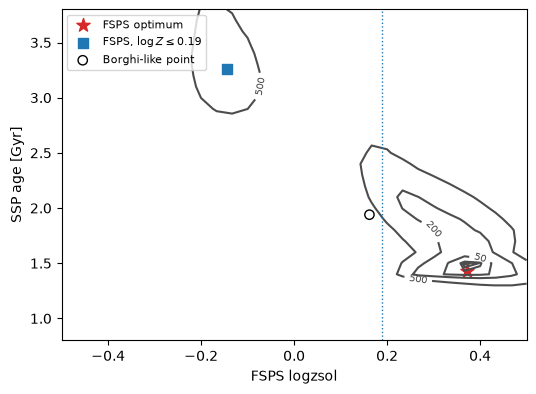

In [28]:
import copy
from scipy.optimize import minimize, minimize_scalar

assert wave.shape == wave_air.shape == spectrum.shape == uncertainty.shape == mask.shape
assert mask.dtype == bool and np.all(mask <= good)
assert np.allclose(wave, air_to_vac(wave_air * u.AA).to_value(u.AA))
assert np.all(wave[mask] > wave_air[mask]) and np.all(np.diff(wave[mask]) > 0)
assert DR2_FLUX_UNIT.unit.is_equivalent(u.erg / u.s / u.cm**2 / u.AA)
assert AB_ZERO_POINT.unit.is_equivalent(u.Jy)
assert np.isclose(
    sigma_expected,
    np.sqrt(sigma_star**2 + sigma_instrument**2 - sigma_miles**2),
)
assert np.isclose(chi2_synth / mask.sum(), 1.0, atol=0.05)
assert np.abs(recovery['pull']).max() < 3

BORGHI_AGE_GYR = 1.94
BORGHI_METALLICITY = 0.162


def make_diagnostic_model(polyorder=10):
    params = copy.deepcopy(model_params)
    params['polyorder']['init'] = int(polyorder)
    return PolySpecModel(params)


def fit_fsps_deterministic(
    *, logzmax=0.5, polyorder=10, fixed_sigma=None, fit_mask=None,
):
    fit_mask = mask.copy() if fit_mask is None else np.asarray(fit_mask, dtype=bool)
    local_obs = dict(obs)
    local_obs['mask'] = fit_mask
    fit = make_diagnostic_model(polyorder)
    names = ['logzsol', 'tage'] + ([] if fixed_sigma is not None else ['sigma_smooth'])
    bounds = [(-1.0, logzmax), (0.5, 4.0)]
    if fixed_sigma is None:
        bounds.append((150.0, 330.0))

    def evaluate(values, return_prediction=False):
        selected = dict(zip(names, values))
        if fixed_sigma is not None:
            selected['sigma_smooth'] = float(fixed_sigma)
        theta = fit.theta.copy()
        for name, value in selected.items():
            theta[fit.theta_index[name]] = value
        prediction, _, _ = fit.predict(theta, obs=local_obs, sps=sps)
        chi2_value = np.sum(
            ((spectrum[fit_mask] - prediction[fit_mask]) / uncertainty[fit_mask]) ** 2
        )
        if return_prediction:
            return chi2_value, prediction, selected
        return chi2_value

    starts = [
        [min(0.37, logzmax - 1e-4), 1.44],
        [logzmax - 1e-4, 2.0],
        [min(0.1, logzmax - 1e-4), 2.8],
        [min(-0.3, logzmax - 1e-4), 3.7],
    ]
    if fixed_sigma is None:
        starts = [start + [250.0] for start in starts]
    attempts = [
        minimize(
            evaluate, start, method='Powell', bounds=bounds,
            options={'xtol': 2e-4, 'ftol': 1e-7, 'maxiter': 300},
        )
        for start in starts
    ]
    optimum = min(attempts, key=lambda result: result.fun)
    chi2_value, prediction, selected = evaluate(optimum.x, return_prediction=True)
    dof_value = fit_mask.sum() - len(names) - (polyorder + 1)
    return {
        **selected,
        'chi2': float(chi2_value),
        'reduced_chi2': float(chi2_value / dof_value),
        'dof': int(dof_value),
        'prediction': prediction,
        'mask': fit_mask,
        'polyorder': int(polyorder),
        'success': bool(optimum.success),
    }


fsps_best = fit_fsps_deterministic()
fsps_capped = fit_fsps_deterministic(logzmax=0.19)

posterior_median = posterior.set_index('parameter')['median']
assert abs(fsps_best['tage'] - posterior_median['tage']) < 0.05
assert abs(fsps_best['logzsol'] - posterior_median['logzsol']) < 0.03
assert abs(fsps_best['sigma_smooth'] - posterior_median['sigma_smooth']) < 5.0
assert abs(fsps_best['reduced_chi2'] - chi2_best / dof) < 0.05

borghi_model = make_diagnostic_model(10)
borghi_obs = dict(obs)
borghi_obs['mask'] = mask


def evaluate_fsps_point(age_gyr, metallicity, sigma_kms):
    theta = borghi_model.theta.copy()
    for name, value in [
        ('tage', age_gyr),
        ('logzsol', metallicity),
        ('sigma_smooth', sigma_kms),
    ]:
        theta[borghi_model.theta_index[name]] = value
    prediction, _, _ = borghi_model.predict(theta, obs=borghi_obs, sps=sps)
    chi2_value = np.sum(((spectrum[mask] - prediction[mask]) / uncertainty[mask]) ** 2)
    return chi2_value, prediction


borghi_sigma_result = minimize_scalar(
    lambda sigma: evaluate_fsps_point(BORGHI_AGE_GYR, BORGHI_METALLICITY, sigma)[0],
    bounds=(150.0, 330.0), method='bounded', options={'xatol': 0.2},
)
borghi_chi2, borghi_prediction = evaluate_fsps_point(
    BORGHI_AGE_GYR, BORGHI_METALLICITY, borghi_sigma_result.x
)
fsps_borghi_point = {
    'tage': BORGHI_AGE_GYR,
    'logzsol': BORGHI_METALLICITY,
    'sigma_smooth': float(borghi_sigma_result.x),
    'chi2': float(borghi_chi2),
    'reduced_chi2': float(borghi_chi2 / dof),
    'dof': int(dof),
    'prediction': borghi_prediction,
    'mask': mask.copy(),
    'polyorder': 10,
}

profile_ages = np.linspace(0.8, 3.8, 31)
profile_metallicities = np.linspace(-0.5, 0.5, 31)
profile_chi2 = np.empty((len(profile_ages), len(profile_metallicities)))
profile_sigma = np.empty_like(profile_chi2)

for age_index, trial_age in enumerate(profile_ages):
    for metal_index, trial_metallicity in enumerate(profile_metallicities):
        sigma_result = minimize_scalar(
            lambda trial_sigma: evaluate_fsps_point(
                trial_age, trial_metallicity, trial_sigma
            )[0],
            bounds=(180.0, 310.0), method='bounded', options={'xatol': 1.0},
        )
        profile_chi2[age_index, metal_index] = sigma_result.fun
        profile_sigma[age_index, metal_index] = sigma_result.x

delta_profile_chi2 = profile_chi2 - profile_chi2.min()
fig, ax = plt.subplots(figsize=(6.0, 4.3))
contours = ax.contour(
    profile_metallicities, profile_ages, delta_profile_chi2,
    levels=[2.30, 6.17, 11.8, 50, 200, 500], colors='0.3',
)
ax.clabel(contours, fontsize=7, fmt='%g')
ax.scatter(fsps_best['logzsol'], fsps_best['tage'], marker='*', s=100,
           color='tab:red', label='FSPS optimum')
ax.scatter(fsps_capped['logzsol'], fsps_capped['tage'], marker='s', s=45,
           color='tab:blue', label=r'FSPS, $\log Z\leq0.19$')
ax.scatter(BORGHI_METALLICITY, BORGHI_AGE_GYR, marker='o', s=45,
           facecolor='none', edgecolor='k', label='Borghi-like point')
ax.axvline(0.19, color='tab:blue', linestyle=':', linewidth=1)
ax.set(xlabel='FSPS logzsol', ylabel='SSP age [Gyr]')
ax.legend(fontsize=8)

print(
    f"deterministic FSPS: age={fsps_best['tage']:.3f} Gyr, "
    f"logzsol={fsps_best['logzsol']:+.3f}, "
    f"sigma={fsps_best['sigma_smooth']:.1f} km/s, "
    f"chi2nu={fsps_best['reduced_chi2']:.3f}"
)


### 8.2 Identify wavelength and nuisance drivers

- attribute the likelihood gain in independent 100-angstrom windows
- refit after removing only the three dominant windows
- test continuum flexibility and velocity broadening separately

In [29]:
rest_wave = wave_air / (1 + z)
delta_chi2_pixel = np.zeros_like(spectrum)
delta_chi2_pixel[mask] = (
    ((spectrum[mask] - fsps_borghi_point['prediction'][mask]) / uncertainty[mask]) ** 2
    - ((spectrum[mask] - fsps_best['prediction'][mask]) / uncertainty[mask]) ** 2
)
assert np.isclose(
    delta_chi2_pixel[mask].sum(),
    fsps_borghi_point['chi2'] - fsps_best['chi2'],
    rtol=0,
    atol=1e-8,
)

feature_ranges = {
    'high-order Balmer': (3780, 3860),
    'CN3883/H8': (3860, 3915),
    'Ca H&K': (3915, 4005),
    'Dn4000 red': (4005, 4080),
    'Hdelta': (4080, 4135),
    'CN/Fe 4140': (4135, 4215),
    'Ca4227/G4300': (4215, 4325),
    'Hgamma': (4325, 4375),
    'Fe4383': (4375, 4440),
    'Fe4531': (4490, 4570),
    'C2 4668': (4620, 4725),
}


def feature_label(low, high):
    labels = [
        name for name, (feature_low, feature_high) in feature_ranges.items()
        if min(high, feature_high) > max(low, feature_low)
    ]
    return '/'.join(labels) if labels else 'continuum/other'


window_edges = np.arange(
    100 * np.floor(rest_wave[mask].min() / 100),
    100 * np.ceil(rest_wave[mask].max() / 100) + 100,
    100,
)
window_rows = []
for low, high in zip(window_edges[:-1], window_edges[1:]):
    selected = mask & (rest_wave >= low) & (rest_wave < high)
    if selected.any():
        window_rows.append({
            'rest_range_A': f'{low:.0f}-{high:.0f}',
            'low': float(low),
            'high': float(high),
            'feature': feature_label(low, high),
            'pixels': int(selected.sum()),
            'delta_chi2': float(delta_chi2_pixel[selected].sum()),
        })

window_diagnostics = pd.DataFrame(window_rows).sort_values(
    'delta_chi2', ascending=False, ignore_index=True
)
assert np.isclose(
    window_diagnostics['delta_chi2'].sum(), delta_chi2_pixel[mask].sum(), atol=1e-8
)
dominant_windows = window_diagnostics.head(3).copy()

masked_refits = {}
for _, region in dominant_windows.iterrows():
    region_mask = mask & ~(
        (rest_wave >= region['low']) & (rest_wave < region['high'])
    )
    assert np.all(region_mask <= mask)
    masked_refits[region['rest_range_A']] = fit_fsps_deterministic(fit_mask=region_mask)

dominant_mask = mask.copy()
for _, region in dominant_windows.iterrows():
    dominant_mask &= ~(
        (rest_wave >= region['low']) & (rest_wave < region['high'])
    )
assert np.all(dominant_mask <= mask)
fsps_without_dominant = fit_fsps_deterministic(fit_mask=dominant_mask)

fsps_poly3 = fit_fsps_deterministic(polyorder=3)
fsps_fixed_sigma = fit_fsps_deterministic(fixed_sigma=sigma_expected)

best_pull = (
    (spectrum[mask] - fsps_best['prediction'][mask]) / uncertainty[mask]
)
centered_pull = best_pull - best_pull.mean()
pull_acf = np.array([
    np.dot(centered_pull[:-lag], centered_pull[lag:])
    / np.dot(centered_pull, centered_pull)
    for lag in range(1, 11)
])
pull_rms = float(np.sqrt(np.mean(best_pull**2)))
error_rescale = float(np.sqrt(fsps_best['reduced_chi2']))

print('largest likelihood gains relative to the Borghi-like point')
display(dominant_windows[['rest_range_A', 'feature', 'pixels', 'delta_chi2']])
display(pd.DataFrame([
    {
        'excluded_rest_range_A': label,
        'age_gyr': result['tage'],
        'logzsol': result['logzsol'],
        'sigma_smooth_kms': result['sigma_smooth'],
        'reduced_chi2': result['reduced_chi2'],
    }
    for label, result in masked_refits.items()
]))
print(
    f'pull RMS={pull_rms:.2f}; lag-1 correlation={pull_acf[0]:.2f}; '
    f'global error rescale for chi2nu=1 is {error_rescale:.2f}'
)


largest likelihood gains relative to the Borghi-like point


,rest_range_A,feature,pixels,delta_chi2
0,3800-3900,high-order Balmer/CN3883/H8,283,428.157414
1,4100-4200,Hdelta/CN/Fe 4140,283,255.695529
2,4200-4300,CN/Fe 4140/Ca4227/G4300,283,92.039520


,excluded_rest_range_A,age_gyr,logzsol,sigma_smooth_kms,reduced_chi2
0,3800-3900,2.988938,-0.124827,239.794220,3.072950
1,4100-4200,1.778259,0.371856,257.711168,3.286712
2,4200-4300,3.575632,-0.135468,249.434891,3.019778


pull RMS=1.79; lag-1 correlation=0.72; global error rescale for chi2nu=1 is 1.80


### 8.3 Compare full-spectrum alpha-MILES

- replace scaled-solar FSPS with the Borghi alpha-MILES family
- preserve data pixels, LSF, polynomial, and likelihood weighting
- compare metallicity axes by name, not numerical equivalence

In [30]:
from milespy import SSPLibrary
from numpy.polynomial.chebyshev import chebvander
from scipy.interpolate import interp1d

alpha_miles = SSPLibrary(
    source='MILES_SSP', version='9.1', isochrone='T', imf_type='bi'
)
alpha_meta = alpha_miles.models.meta
alpha_select = (
    np.isclose(alpha_meta['imf_slope'].value, 1.3)
    & np.isfinite(alpha_meta['alpha'].value)
    & (alpha_meta['age'].value >= 0.5)
    & (alpha_meta['age'].value <= 4.0)
)
alpha_wave = alpha_miles.models.spectral_axis.to_value(u.AA)
alpha_flux = alpha_miles.models.flux[alpha_select].value
alpha_ages = alpha_meta['age'].value[alpha_select]
alpha_metallicities = alpha_meta['met'].value[alpha_select]
alpha_values = alpha_meta['alpha'].value[alpha_select]

alpha_data = flux_dr2[mask]
alpha_errors = err_dr2[mask]
alpha_rest_wave = wave_air[mask] / (1 + z)
alpha_x = alpha_rest_wave - alpha_rest_wave.min()
alpha_x = 2 * alpha_x / np.ptp(alpha_x) - 1
alpha_design = chebvander(alpha_x, 10)


def smooth_alpha_grid(flux_grid, sigma_pixels):
    sigma_pixels = np.clip(sigma_pixels, 0.01, None)
    radius = int(np.ceil(4 * sigma_pixels.max()))
    output = np.zeros_like(flux_grid)
    normalization = np.zeros(flux_grid.shape[1])
    indices = np.arange(flux_grid.shape[1])
    for offset in range(-radius, radius + 1):
        source_indices = indices + offset
        valid = (source_indices >= 0) & (source_indices < flux_grid.shape[1])
        weights = np.exp(-0.5 * (offset / sigma_pixels) ** 2)
        output[:, valid] += flux_grid[:, source_indices[valid]] * weights[valid]
        normalization[valid] += weights[valid]
    return output / normalization


def fit_alpha_miles_at_sigma(sigma_star_kms):
    target_fwhm = alpha_wave * np.hypot(
        1 / LEGAC_R, SIGMA_TO_FWHM * sigma_star_kms / C_KMS
    )
    kernel_sigma = np.sqrt(np.clip(target_fwhm**2 - MILES_FWHM_AA**2, 0, None))
    kernel_sigma /= SIGMA_TO_FWHM
    sigma_pixels = kernel_sigma / np.median(np.diff(alpha_wave))
    broadened = smooth_alpha_grid(alpha_flux, sigma_pixels)
    projected = interp1d(
        alpha_wave, broadened, axis=1, bounds_error=False, fill_value=np.nan
    )(alpha_rest_wave)

    chi2_values = np.full(projected.shape[0], np.inf)
    for template_index, template in enumerate(projected):
        if not np.isfinite(template).all() or np.any(template <= 0):
            continue
        template = template * np.median(alpha_data) / np.median(template)
        matrix = alpha_design * template[:, None]
        coefficients, _, _, _ = np.linalg.lstsq(
            matrix / alpha_errors[:, None], alpha_data / alpha_errors
        )
        prediction = matrix @ coefficients
        chi2_values[template_index] = np.sum(
            ((alpha_data - prediction) / alpha_errors) ** 2
        )
    best_index = int(np.argmin(chi2_values))
    return float(chi2_values[best_index]), best_index


alpha_sigma_trials = np.arange(200.0, 281.0, 20.0)
alpha_trials = []
for alpha_sigma in alpha_sigma_trials:
    alpha_chi2, alpha_row = fit_alpha_miles_at_sigma(alpha_sigma)
    alpha_trials.append((alpha_chi2, alpha_row, alpha_sigma))

alpha_chi2, alpha_row, alpha_sigma = min(alpha_trials)
alpha_dof = mask.sum() - 4 - 11
alpha_miles_best = {
    'tage': float(alpha_ages[alpha_row]),
    'metallicity': float(alpha_metallicities[alpha_row]),
    'alpha': float(alpha_values[alpha_row]),
    'sigma': float(alpha_sigma),
    'chi2': float(alpha_chi2),
    'reduced_chi2': float(alpha_chi2 / alpha_dof),
}

assert np.isfinite(alpha_chi2)
assert np.abs(recovery['pull']).max() < 3


def fsps_result_row(configuration, result, metallicity_axis='FSPS logzsol'):
    return {
        'configuration': configuration,
        'age_gyr': result['tage'],
        'metallicity': result['logzsol'],
        'metallicity_axis': metallicity_axis,
        'alpha_fe': np.nan,
        'broadening_kms': result['sigma_smooth'],
        'broadening_definition': 'extra sigma_smooth',
        'reduced_chi2': result['reduced_chi2'],
        'age_minus_borghi_gyr': result['tage'] - BORGHI_AGE_GYR,
    }


result_rows = [
    fsps_result_row('FSPS degree 10', fsps_best),
    fsps_result_row('FSPS Borghi-like point', fsps_borghi_point),
    fsps_result_row('FSPS logzsol <= 0.19', fsps_capped),
    fsps_result_row('FSPS degree 3', fsps_poly3),
    fsps_result_row('FSPS fixed broadening', fsps_fixed_sigma),
    *[
        fsps_result_row(f'FSPS omit {label} A', result)
        for label, result in masked_refits.items()
    ],
    fsps_result_row('FSPS omit top 3 windows', fsps_without_dominant),
    {
        'configuration': 'alpha-MILES full spectrum',
        'age_gyr': alpha_miles_best['tage'],
        'metallicity': alpha_miles_best['metallicity'],
        'metallicity_axis': 'MILES [M/H]',
        'alpha_fe': alpha_miles_best['alpha'],
        'broadening_kms': alpha_miles_best['sigma'],
        'broadening_definition': 'target sigma_star',
        'reduced_chi2': alpha_miles_best['reduced_chi2'],
        'age_minus_borghi_gyr': alpha_miles_best['tage'] - BORGHI_AGE_GYR,
    },
]
result_table = pd.DataFrame(result_rows)

print(
    f"age shift from degree 10 to degree 3: "
    f"{fsps_poly3['tage'] - fsps_best['tage']:+.2f} Gyr"
)
print(
    f"age shift when broadening is fixed: "
    f"{fsps_fixed_sigma['tage'] - fsps_best['tage']:+.2f} Gyr"
)
print(
    f"age shift from FSPS to alpha-MILES: "
    f"{alpha_miles_best['tage'] - fsps_best['tage']:+.2f} Gyr"
)
result_table.round(3)


age shift from degree 10 to degree 3: +0.46 Gyr
age shift when broadening is fixed: -0.02 Gyr
age shift from FSPS to alpha-MILES: +0.32 Gyr


,configuration,age_gyr,metallicity,metallicity_axis,alpha_fe,broadening_kms,broadening_definition,reduced_chi2,age_minus_borghi_gyr
0,FSPS degree 10,1.434,0.371,FSPS logzsol,NaN,254.658,extra sigma_smooth,3.232,-0.506
1,FSPS Borghi-like point,1.940,0.162,FSPS logzsol,NaN,247.974,extra sigma_smooth,3.420,0.000
2,FSPS logzsol <= 0.19,3.263,-0.143,FSPS logzsol,NaN,240.131,extra sigma_smooth,3.332,1.323
3,FSPS degree 3,1.893,0.365,FSPS logzsol,NaN,259.612,extra sigma_smooth,3.792,-0.047
4,FSPS fixed broadening,1.413,0.332,FSPS logzsol,NaN,222.872,extra sigma_smooth,3.336,-0.527
5,FSPS omit 3800-3900 A,2.989,-0.125,FSPS logzsol,NaN,239.794,extra sigma_smooth,3.073,1.049
6,FSPS omit 4100-4200 A,1.778,0.372,FSPS logzsol,NaN,257.711,extra sigma_smooth,3.287,-0.162
7,FSPS omit 4200-4300 A,3.576,-0.135,FSPS logzsol,NaN,249.435,extra sigma_smooth,3.020,1.636
8,FSPS omit top 3 windows,3.117,-0.138,FSPS logzsol,NaN,244.615,extra sigma_smooth,2.912,1.177
9,alpha-MILES full spectrum,1.750,0.400,MILES [M/H],0.0,260.000,target sigma_star,3.010,-0.190
